In [ ]:
# ============================================================
# 03 - ENTRENAMIENTO Y VALIDACIÓN DEL MODELO
# Proyecto: Clasificación de radiografías NORMAL vs PNEUMONIA
# ============================================================

"""
Objetivo del notebook:
Entrenar y validar de manera preliminar un modelo de reconocimiento
de patrones para clasificar radiografías de tórax en dos clases:

0 = NORMAL
1 = PNEUMONIA

Este notebook corresponde al Avance 4 del proyecto, centrado en:
- carga de datos procesados,
- entrenamiento del modelo,
- validación,
- generación de métricas,
- visualización de resultados,
- análisis preliminar del desempeño.
"""

'\nObjetivo del notebook:\nEntrenar y validar de manera preliminar un modelo de reconocimiento\nde patrones para clasificar radiografías de tórax en dos clases:\n\n0 = NORMAL\n1 = PNEUMONIA\n\nEste notebook corresponde al Avance 4 del proyecto, centrado en:\n- carga de datos procesados,\n- entrenamiento del modelo,\n- validación,\n- generación de métricas,\n- visualización de resultados,\n- análisis preliminar del desempeño.\n'

In [ ]:
# ============================================================
# 1. CONEXIÓN A GOOGLE DRIVE E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

"""
En esta sección se conecta Google Drive para acceder al dataset
almacenado en la carpeta del proyecto. Además, se importan las
librerías necesarias para:

- cargar imágenes,
- construir datasets de TensorFlow,
- entrenar modelos de Deep Learning,
- calcular métricas,
- visualizar resultados.
"""

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import pandas as pd
import seaborn as sns

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. DEFINICIÓN DE RUTA Y PARÁMETROS GENERALES
# ============================================================

"""
Para este avance se trabajará únicamente con la carpeta train,
debido a que contiene la mayor cantidad de imágenes disponibles.

A partir de esta carpeta se realizará una nueva división interna:
- entrenamiento
- validación

La división será estratificada para conservar la proporción entre
las clases NORMAL y PNEUMONIA.
"""

BASE = Path('/content/drive/MyDrive/2026/proyecto_patrones/XRAY')

TRAIN_ORIGINAL_DIR = BASE / 'train'

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

print("Ruta train existe:", TRAIN_ORIGINAL_DIR.exists())

Ruta train existe: True


In [ ]:
# ============================================================
# 3. VERIFICACIÓN DE IMÁGENES EN TRAIN
# ============================================================

"""
Se verifica la cantidad de imágenes disponibles en la carpeta train
para cada clase. Esta información permite identificar el tamaño real
del conjunto de trabajo y evaluar si existe desbalance entre clases.
"""

CLASES = ['NORMAL', 'PNEUMONIA']

image_paths = []
labels = []

for idx, clase in enumerate(CLASES):
    carpeta = TRAIN_ORIGINAL_DIR / clase
    archivos = list(carpeta.glob('*'))

    print(f"{clase}: {len(archivos)} imágenes")

    for archivo in archivos:
        image_paths.append(str(archivo))
        labels.append(idx)

print("\nTotal de imágenes usadas:", len(image_paths))
print("0 = NORMAL")
print("1 = PNEUMONIA")

NORMAL: 1341 imágenes
PNEUMONIA: 3875 imágenes

Total de imágenes usadas: 5216
0 = NORMAL
1 = PNEUMONIA


In [ ]:
# ============================================================
# 4. DIVISIÓN ESTRATIFICADA TRAIN / VALIDATION
# ============================================================

"""
A partir de la carpeta train original se crea una división interna
para entrenamiento y validación.

Se utiliza una división estratificada 80/20:
- 80% para entrenamiento
- 20% para validación

Esto permite validar el modelo con una cantidad suficiente de imágenes
y mantener una proporción similar de clases en ambos subconjuntos.
"""

from sklearn.model_selection import train_test_split
from collections import Counter

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=SEED
)

print("Entrenamiento:", len(X_train), Counter(y_train))
print("Validación:", len(X_val), Counter(y_val))

Entrenamiento: 4172 Counter({1: 3099, 0: 1073})
Validación: 1044 Counter({1: 776, 0: 268})


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(class_weights[0]),
    1: float(class_weights[1])
}

print(class_weights)


{0: 1.9440820130475303, 1: 0.6731203614069055}


In [ ]:
# ============================================================
# 5. CREACIÓN DE DATASETS CON TENSORFLOW
# ============================================================

"""
En esta sección se convierten las rutas de imágenes y sus etiquetas
en datasets de TensorFlow usando un subconjunto pequeño de prueba.
"""

from sklearn.model_selection import train_test_split
from collections import Counter

AUTOTUNE = tf.data.AUTOTUNE

# 5.1 FUNCIÓN ÚNICA DE CARGA: Configurada para imágenes médicas (JPG/PNG)
def cargar_imagen(path, label):
    imagen = tf.io.read_file(path)
    imagen = tf.image.decode_jpeg(imagen, channels=1)
    imagen = tf.image.resize(imagen, [IMG_SIZE, IMG_SIZE])
    imagen = tf.cast(imagen, tf.float32) / 255.0  # Escalado base inicial
    return imagen, label

# 5.2 GENERACIÓN DEL DATASET PEQUEÑO DE PRUEBA
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=1000,
    stratify=y_train,
    random_state=SEED
)

X_val_small, _, y_val_small, _ = train_test_split(
    X_val,
    y_val,
    train_size=250,
    stratify=y_val,
    random_state=SEED
)

print("Train pequeño para pruebas:", len(X_train_small), Counter(y_train_small))
print("Val pequeño para pruebas:", len(X_val_small), Counter(y_val_small))

# 5.3 CONSTRUCCIÓN DE PIPELINES DE TENSORFLOW
train_ds = tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
val_ds = tf.data.Dataset.from_tensor_slices((X_val_small, y_val_small))

train_ds = train_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(
    buffer_size=1000,
    seed=SEED
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("\nDatasets optimizados creados correctamente.")

# 5.4 VERIFICACIÓN DE TENSORES
for imagenes, etiquetas in train_ds.take(1):
    print("Forma del lote de imágenes:", imagenes.shape)
    print("Forma del lote de etiquetas:", etiquetas.shape)
    print("Valor mínimo del píxel:", tf.reduce_min(imagenes).numpy())
    print("Valor máximo del píxel:", tf.reduce_max(imagenes).numpy())

Dataset de entrenamiento creado correctamente
Dataset de validación creado correctamente


In [ ]:
def cargar_imagen(path, label):

    imagen = tf.io.read_file(path)

    imagen = tf.image.decode_jpeg(
        imagen,
        channels=1
    )

    imagen = tf.image.resize(
        imagen,
        [IMG_SIZE, IMG_SIZE]
    )

    imagen = tf.cast(
        imagen,
        tf.float32
    ) / 255.0

    return imagen, label

In [ ]:
# ============================================================
# 5. CREACIÓN DE DATASETS CON TENSORFLOW
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

# UNA SOLA FUNCIÓN: Usamos decode_jpeg ya que son radiografías (imágenes médicas)
def cargar_imagen(path, label):
    imagen = tf.io.read_file(path)
    # decode_jpeg funciona excelente para archivos JPG/PNG radiográficos de 1 canal (escala de grises)
    imagen = tf.image.decode_jpeg(imagen, channels=1)
    imagen = tf.image.resize(imagen, [IMG_SIZE, IMG_SIZE])
    imagen = tf.cast(imagen, tf.float32) / 255.0  # Escalado base inicial
    return imagen, label

# A partir de aquí tu código sigue igual para crear los datasets...
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
# ... (el resto de los mapeos y shuffles se quedan tal cual los tenías)

Train pequeño: 1000 Counter({1: 743, 0: 257})
Val pequeño: 250 Counter({1: 186, 0: 64})


In [ ]:
# Crear datasets TensorFlow

train_ds = tf.data.Dataset.from_tensor_slices((X_train_small, y_train_small))
val_ds = tf.data.Dataset.from_tensor_slices((X_val_small, y_val_small))

train_ds = train_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(
    buffer_size=1000,
    seed=SEED
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets pequeños creados correctamente")

Datasets pequeños creados correctamente


In [ ]:
for imagenes, etiquetas in train_ds.take(1):
    print("Forma imágenes:", imagenes.shape)
    print("Forma etiquetas:", etiquetas.shape)
    print("Valor mínimo:", tf.reduce_min(imagenes).numpy())
    print("Valor máximo:", tf.reduce_max(imagenes).numpy())

Forma imágenes: (32, 224, 224, 1)
Forma etiquetas: (32,)
Valor mínimo: 0.0
Valor máximo: 1.0


In [ ]:
# ============================================================
# 6. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    # Varía el contraste aleatoriamente entre el 80% y el 120% en cada época
    tf.keras.layers.RandomContrast(factor=0.2, seed=SEED)
], name="data_augmentation")

print("Data augmentation con contraste definido correctamente")

Data augmentation definido correctamente


In [ ]:
# ============================================================
# 7. MODELO BASELINE CNN SIMPLE
# ============================================================

"""
Se define un modelo CNN simple como baseline.

Este modelo servirá como punto de comparación frente a modelos
más avanzados que puedan implementarse posteriormente.

Arquitectura:
- Entrada 224x224x1
- Data Augmentation
- Capas convolucionales
- MaxPooling
- GlobalAveragePooling
- Capa densa
- Dropout
- Salida sigmoide para clasificación binaria
"""

modelo_baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 8. COMPILACIÓN DEL MODELO BASELINE
# ============================================================

modelo_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("Modelo baseline compilado correctamente")

Modelo baseline compilado correctamente


In [ ]:
# ============================================================
# 9. ENTRENAMIENTO PRELIMINAR DEL MODELO BASELINE
# ============================================================

EPOCHS = 5

history_baseline = modelo_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.4320 - auc: 0.5052 - loss: 0.6946 - precision: 0.7536 - recall: 0.3499 - val_accuracy: 0.7440 - val_auc: 0.6667 - val_loss: 0.6905 - val_precision: 0.7480 - val_recall: 0.9892
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.4470 - auc: 0.5057 - loss: 0.6941 - precision: 0.7500 - recall: 0.3836 - val_accuracy: 0.2560 - val_auc: 0.8693 - val_loss: 0.7057 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 124s 4s/step - accuracy: 0.3090 - auc: 0.5944 - loss: 0.6909 - precision: 0.9194 - recall: 0.0767 - val_accuracy: 0.6520 - val_auc: 0.7985 - val_loss: 0.6902 - val_precision: 0.9806 - val_recall: 0.5430
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.4690 - auc: 0.6764 - loss: 0.6767 - precision: 0.9240 - recall: 0.3109 - val_accuracy: 0.7080 - val_auc: 0.8699 - val_loss: 0.6670 - val_precision: 0.9829 - val_recall: 0.6183
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━

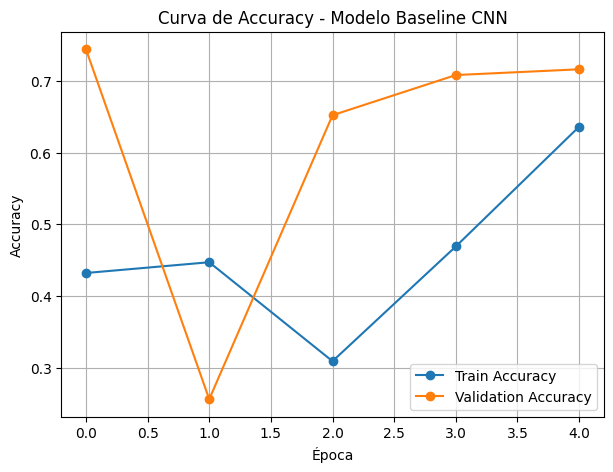

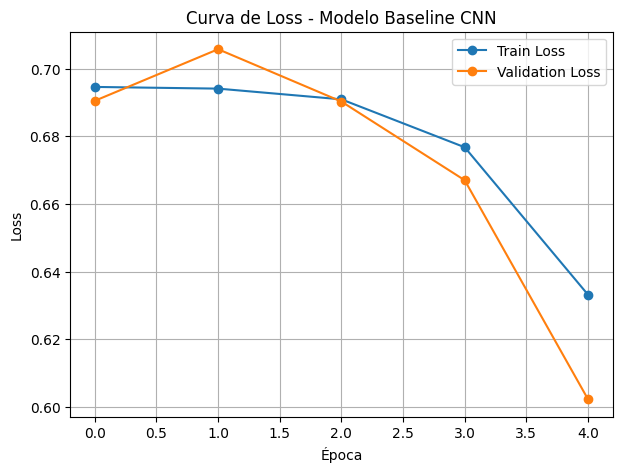

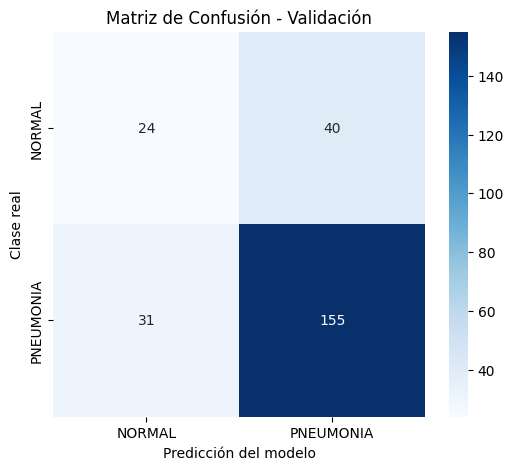

,Métrica,Valor,Porcentaje
0,Accuracy,0.716000,71.60%
1,Precision,0.794872,79.49%
2,Recall,0.833333,83.33%
3,Sensibilidad,0.833333,83.33%
4,Especificidad,0.375000,37.50%
5,F1-score,0.813648,81.36%
6,AUC-ROC,0.770497,77.05%


,precision,recall,f1-score,support
NORMAL,0.436364,0.375000,0.403361,64.000
PNEUMONIA,0.794872,0.833333,0.813648,186.000
accuracy,0.716000,0.716000,0.716000,0.716
macro avg,0.615618,0.604167,0.608505,250.000
weighted avg,0.703094,0.716000,0.708615,250.000


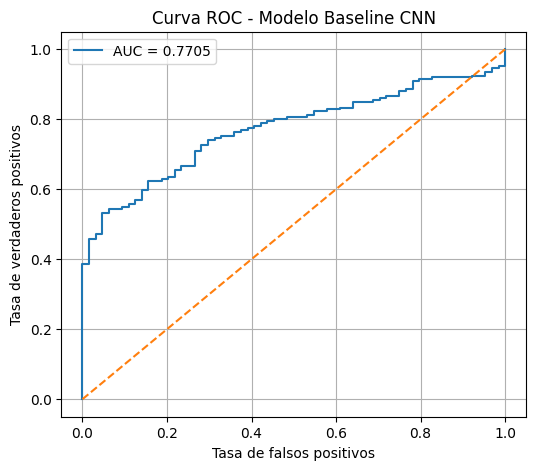

,Experimento,Modelo,Dataset,Train,Validation,Batch Size,Epochs,Learning Rate,Loss,Optimizador,Class Weights,Accuracy Val,Precision Val,Recall/Sensibilidad Val,Especificidad Val,F1 Val,AUC Val,Observación
0,EXP-01,CNN Baseline,Subconjunto estratificado,1000,250,32,5,0.001,Binary Crossentropy,Adam,"{0: 1.9440820130475303, 1: 0.6731203614069055}",71.60%,79.49%,83.33%,37.50%,81.36%,77.05%,Prueba preliminar con CNN simple


In [ ]:
# ============================================================
# 10. CURVAS DE ENTRENAMIENTO Y VALIDACIÓN
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(history_baseline.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Curva de Accuracy - Modelo Baseline CNN')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(history_baseline.history['loss'], marker='o', label='Train Loss')
plt.plot(history_baseline.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Curva de Loss - Modelo Baseline CNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 11. PREDICCIONES SOBRE VALIDACIÓN
# ============================================================

y_true = []
y_prob = []

for imagenes, etiquetas in val_ds:
    probabilidades = modelo_baseline.predict(imagenes, verbose=0)
    y_prob.extend(probabilidades.ravel())
    y_true.extend(etiquetas.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)


# ============================================================
# 12. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción del modelo')
plt.ylabel('Clase real')
plt.show()


# ============================================================
# 13. MÉTRICAS DE CLASIFICACIÓN
# ============================================================

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
sensibilidad = recall
especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
auc = roc_auc_score(y_true, y_prob)

metricas = pd.DataFrame({
    'Métrica': [
        'Accuracy',
        'Precision',
        'Recall',
        'Sensibilidad',
        'Especificidad',
        'F1-score',
        'AUC-ROC'
    ],
    'Valor': [
        accuracy,
        precision,
        recall,
        sensibilidad,
        especificidad,
        f1,
        auc
    ],
    'Porcentaje': [
        f'{accuracy*100:.2f}%',
        f'{precision*100:.2f}%',
        f'{recall*100:.2f}%',
        f'{sensibilidad*100:.2f}%',
        f'{especificidad*100:.2f}%',
        f'{f1*100:.2f}%',
        f'{auc*100:.2f}%'
    ]
})

display(metricas)


# ============================================================
# 14. REPORTE DE CLASIFICACIÓN POR CLASE
# ============================================================

reporte = classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    output_dict=True
)

reporte_df = pd.DataFrame(reporte).transpose()
display(reporte_df)


# ============================================================
# 15. CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('Curva ROC - Modelo Baseline CNN')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 16. TABLA DE SEGUIMIENTO DE EXPERIMENTO
# ============================================================

experimento = pd.DataFrame({
    'Experimento': ['EXP-01'],
    'Modelo': ['CNN Baseline'],
    'Dataset': ['Subconjunto estratificado'],
    'Train': [len(X_train_small)],
    'Validation': [len(X_val_small)],
    'Batch Size': [BATCH_SIZE],
    'Epochs': [EPOCHS],
    'Learning Rate': [0.001],
    'Loss': ['Binary Crossentropy'],
    'Optimizador': ['Adam'],
    'Class Weights': [str(class_weights)],
    'Accuracy Val': [f'{accuracy*100:.2f}%'],
    'Precision Val': [f'{precision*100:.2f}%'],
    'Recall/Sensibilidad Val': [f'{recall*100:.2f}%'],
    'Especificidad Val': [f'{especificidad*100:.2f}%'],
    'F1 Val': [f'{f1*100:.2f}%'],
    'AUC Val': [f'{auc*100:.2f}%'],
    'Observación': ['Prueba preliminar con CNN simple']
})

display(experimento)